# CAP4770 Final Project – Data Exploration & Preprocessing

## Objective
- Understand dataset structure
- Analyze class imbalance
- Prepare data for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Load the dataset
df = pd.read_csv("../data/BitcoinHeistData.csv")
df.head()

,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.008333,1,0,2,100050000.0,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.000244,1,0,1,100000000.0,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.000000,1,0,2,200000000.0,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.003906,1,0,2,71200000.0,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.072848,456,0,1,200000000.0,princetonLocky


In [13]:
# Basic exploration
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nSummary statistics:")
df.describe()

Shape: (2916697, 10)

Columns:
Index(['address', 'year', 'day', 'length', 'weight', 'count', 'looped',
       'neighbors', 'income', 'label'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2916697 entries, 0 to 2916696
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   address    str    
 1   year       int64  
 2   day        int64  
 3   length     int64  
 4   weight     float64
 5   count      int64  
 6   looped     int64  
 7   neighbors  int64  
 8   income     float64
 9   label      str    
dtypes: float64(2), int64(6), str(2)
memory usage: 222.5 MB

Summary statistics:


,year,day,length,weight,count,looped,neighbors,income
count,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06,2.916697e+06
mean,2.014475e+03,1.814572e+02,4.500859e+01,5.455192e-01,7.216446e+02,2.385067e+02,2.206516e+00,4.464889e+09
std,2.257398e+00,1.040118e+02,5.898236e+01,3.674255e+00,1.689676e+03,9.663217e+02,1.791877e+01,1.626860e+11
min,2.011000e+03,1.000000e+00,0.000000e+00,3.606469e-94,1.000000e+00,0.000000e+00,1.000000e+00,3.000000e+07
25%,2.013000e+03,9.200000e+01,2.000000e+00,2.148438e-02,1.000000e+00,0.000000e+00,1.000000e+00,7.428559e+07
50%,2.014000e+03,1.810000e+02,8.000000e+00,2.500000e-01,1.000000e+00,0.000000e+00,2.000000e+00,1.999985e+08
75%,2.016000e+03,2.710000e+02,1.080000e+02,8.819482e-01,5.600000e+01,0.000000e+00,2.000000e+00,9.940000e+08
max,2.018000e+03,3.650000e+02,1.440000e+02,1.943749e+03,1.449700e+04,1.449600e+04,1.292000e+04,4.996440e+13


In [14]:
# Original label distribution
df['label'].value_counts()

label
white                          2875284
paduaCryptoWall                  12390
montrealCryptoLocker              9315
princetonCerber                   9223
princetonLocky                    6625
montrealCryptXXX                  2419
montrealNoobCrypt                  483
montrealDMALockerv3                354
montrealDMALocker                  251
montrealSamSam                      62
montrealCryptoTorLocker2015         55
montrealGlobeImposter               55
montrealGlobev3                     34
montrealGlobe                       32
montrealWannaCry                    28
montrealRazy                        13
montrealAPT                         11
paduaKeRanger                       10
montrealFlyper                       9
montrealXTPLocker                    8
montrealVenusLocker                  7
montrealXLockerv5.0                  7
montrealCryptConsole                 7
montrealEDA2                         6
montrealJigSaw                       4
paduaJigsaw        

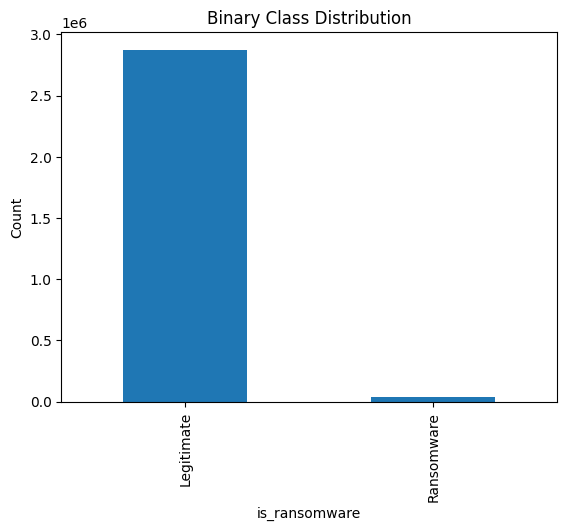

In [15]:
# Convert to binary classification target:
# 0 = legitimate ("white"), 1 = ransomware (all other labels)
df['is_ransomware'] = df['label'].apply(lambda x: 0 if x == 'white' else 1)

df['is_ransomware'].value_counts().plot(kind='bar')
plt.xticks([0, 1], ['Legitimate', 'Ransomware'])
plt.title("Binary Class Distribution")
plt.xlabel("is_ransomware")
plt.ylabel("Count")
plt.show()

## Observations

The dataset contains over 2.9 million samples, which introduces computational considerations and reinforces the need for efficient preprocessing and modeling.

The dataset is highly imbalanced, with the majority of samples labeled as legitimate ("white") and relatively few ransomware instances. This imbalance makes accuracy an unreliable metric and motivates the use of precision, recall, and F1-score, as well as techniques such as class weighting or SMOTE.

The dataset was converted from a multi-class labeling scheme into a binary classification problem, where all ransomware families are grouped into a single class. This allows us to focus on distinguishing malicious behavior from legitimate activity, which aligns with the project objective.

In [16]:
# Check for missing values and duplicates
print("Missing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values by column:
address          0
year             0
day              0
length           0
weight           0
count            0
looped           0
neighbors        0
income           0
label            0
is_ransomware    0
dtype: int64

Duplicate rows:
0


In [17]:
X = df.drop(columns=['label', 'is_ransomware'])
X = X.select_dtypes(include=['number'])

y = df['is_ransomware'].astype(int)

In [18]:
# Preview processed features
X.head()

,year,day,length,weight,count,looped,neighbors,income
0,2017,11,18,0.008333,1,0,2,100050000.0
1,2016,132,44,0.000244,1,0,1,100000000.0
2,2016,246,0,1.000000,1,0,2,200000000.0
3,2016,322,72,0.003906,1,0,2,71200000.0
4,2016,238,144,0.072848,456,0,1,200000000.0


In [19]:
# Confirm final shapes
X.shape, y.shape

((2916697, 8), (2916697,))

In [20]:
# Scale features to normalize ranges for improved model performance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Additional Observation

After preprocessing, the feature set contains only numeric behavioral features, making it suitable for standard machine learning models without additional encoding.

In [21]:
# Save processed data for Notebook 2
pd.DataFrame(X_scaled).to_csv("../data/X_scaled.csv", index=False)
y.to_csv("../data/y_binary.csv", index=False)

## Next Steps

- Train a baseline classification model
- Evaluate precision, recall, and F1-score
- Compare results before and after dimensionality reduction
- Test class imbalance handling methods such as class weighting or SMOTE